# 02 — Exploratory Data Analysis

Load the processed dataset and characterise the sample, biomarker distributions, and preliminary associations with depression.

In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
PROCESSED = Path('../data/processed')
FIGURES   = Path('../figures')
FIGURES.mkdir(exist_ok=True)

df = pd.read_parquet(PROCESSED / 'nhanes_analysis_ready.parquet', engine='fastparquet')

PHQ_ITEMS = [f'DPQ0{i}0' for i in range(1, 10)]
ITEM_LABELS = {
    'DPQ010': 'Anhedonia',    'DPQ020': 'Depressed mood', 'DPQ030': 'Sleep',
    'DPQ040': 'Fatigue',      'DPQ050': 'Appetite',        'DPQ060': 'Self-worth',
    'DPQ070': 'Concentration','DPQ080': 'Psychomotor',     'DPQ090': 'Suicidality',
}
BIOMARKER_LABELS = {
    'log_CRP':      'log(CRP+1) mg/dL',
    'log_WBC':      'log(WBC) 1000/uL',
    'LBXNEPCT':     'Neutrophil %',
    'LBXLYPCT':     'Lymphocyte %',
    'log_NLR':      'log(NLR)',
    'LBXSAL':       'Albumin g/dL',
    'log_ferritin': 'log(Ferritin) ng/mL',
}

# Recover raw CRP and ferritin from log versions for display
df['CRP_raw']      = np.exp(df['log_CRP']) - 1
df['ferritin_raw'] = np.exp(df['log_ferritin'])

print(f'Analysis-ready N = {len(df):,}')
df.head(3)

Analysis-ready N = 1,689


,SEQN,WTPOOL,SDMVPSU,SDMVSTRA,cycle,PHQ9_total,depression,DPQ010,DPQ020,DPQ030,...,LBXFER,log_ferritin,RIDAGEYR,RIAGENDR,BMXBMI,SMQ040_bin,ALQ130,RIDRETH3,CRP_raw,ferritin_raw
0,83752.0,19340.265630,1.0,124.0,I,1.0,0.0,0.0,0.0,0.0,...,107.0,4.672829,30.0,2.0,26.6,0.0,2.0,2.0,0.9,107.0
1,83851.0,36578.543407,1.0,120.0,I,0.0,0.0,0.0,0.0,0.0,...,40.3,3.696351,37.0,2.0,35.3,1.0,1.0,3.0,2.8,40.3
2,83865.0,31522.434952,2.0,126.0,I,7.0,0.0,1.0,1.0,2.0,...,30.4,3.414443,21.0,2.0,16.3,1.0,4.0,3.0,0.5,30.4


## 1. Weighted Sample Characteristics (Table 1)

In [28]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    return np.average(series[mask], weights=weights[mask])

def weighted_std(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    m = weighted_mean(series[mask], weights[mask])
    return np.sqrt(np.average((series[mask] - m)**2, weights=weights[mask]))

def weighted_prop(binary_series, weights):
    mask = binary_series.notna() & weights.notna() & (weights > 0)
    return np.average(binary_series[mask], weights=weights[mask])

groups = {
    'Overall':       df,
    'Non-depressed': df[df['depression'] == 0],
    'Depressed':     df[df['depression'] == 1],
}

rows = {}
for name, g in groups.items():
    w = g['WTPOOL']
    rows[name] = {
        'N (unweighted)':         len(g),
        'Age mean (SD)':          f'{weighted_mean(g["RIDAGEYR"], w):.1f} ({weighted_std(g["RIDAGEYR"], w):.1f})',
        'Female %':               f'{weighted_prop(g["RIAGENDR"].eq(2).astype(float), w)*100:.1f}',
        'BMI mean (SD)':          f'{weighted_mean(g["BMXBMI"], w):.1f} ({weighted_std(g["BMXBMI"], w):.1f})',
        'Current smoker %':       f'{weighted_prop(g["SMQ040_bin"], w)*100:.1f}',
        'PHQ-9 mean (SD)':        f'{weighted_mean(g["PHQ9_total"], w):.1f} ({weighted_std(g["PHQ9_total"], w):.1f})',
        'CRP median (mg/dL)':     f'{g["CRP_raw"].median():.2f}',
        'WBC mean (1000/uL)':     f'{weighted_mean(g["LBXWBCSI"], w):.2f}',
        'Neutrophil % mean':      f'{weighted_mean(g["LBXNEPCT"], w):.1f}',
        'Lymphocyte % mean':      f'{weighted_mean(g["LBXLYPCT"], w):.1f}',
        'NLR median':             f'{g["NLR"].median():.2f}',
        'Albumin mean (g/dL)':    f'{weighted_mean(g["LBXSAL"], w):.2f}',
        'Ferritin median (ng/mL)':f'{g["ferritin_raw"].median():.1f}',
    }

table1 = pd.DataFrame(rows)
print(table1.to_string())

                             Overall Non-depressed    Depressed
N (unweighted)                  1689          1465          224
Age mean (SD)            45.1 (16.1)   45.7 (16.2)  41.1 (15.0)
Female %                        50.9          48.9         64.5
BMI mean (SD)             30.1 (7.6)    29.9 (7.4)   31.4 (8.7)
Current smoker %                44.4          41.5         63.0
PHQ-9 mean (SD)            4.1 (4.8)     2.5 (2.6)   14.0 (3.9)
CRP median (mg/dL)              2.08          2.00         2.91
WBC mean (1000/uL)              7.81          7.70         8.46
Neutrophil % mean               58.1          58.0         59.0
Lymphocyte % mean               30.5          30.6         29.8
NLR median                      1.92          1.91         1.98
Albumin mean (g/dL)             4.13          4.14         4.07
Ferritin median (ng/mL)        105.0         112.0         74.0


## 2. PHQ-9 Score Distribution and Depression Prevalence

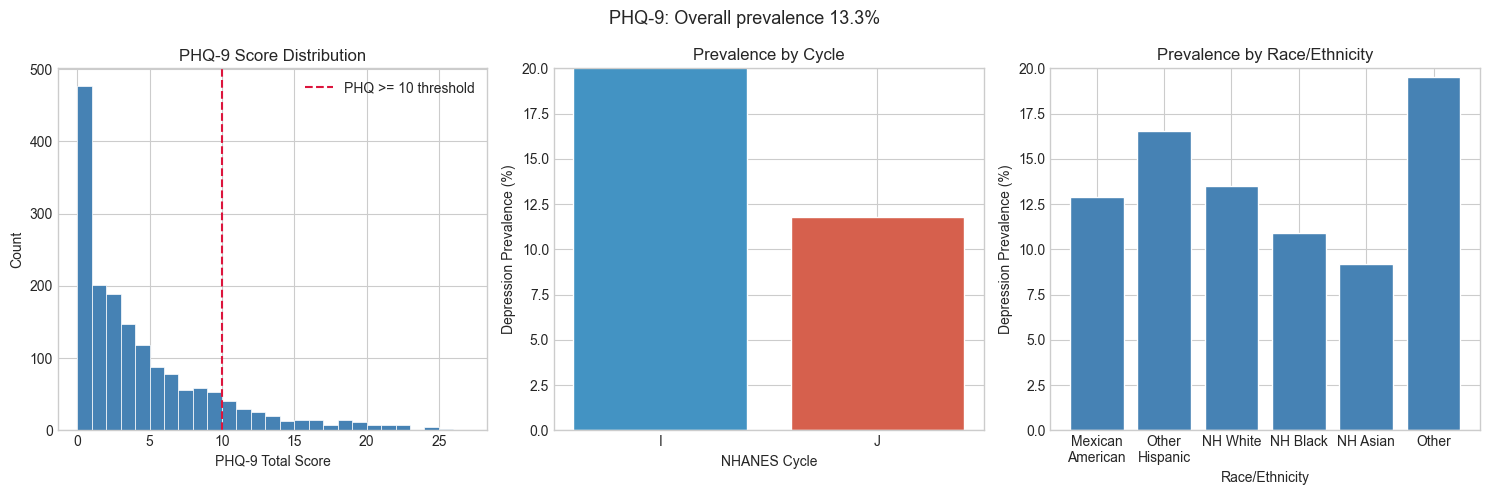

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['PHQ9_total'], bins=range(28), color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(x=10, color='crimson', linestyle='--', linewidth=1.5,
                label='PHQ >= 10 threshold')
axes[0].set_xlabel('PHQ-9 Total Score')
axes[0].set_ylabel('Count')
axes[0].set_title('PHQ-9 Score Distribution')
axes[0].legend()

cycle_prev = df.groupby('cycle')['depression'].mean() * 100
axes[1].bar(cycle_prev.index, cycle_prev.values,
            color=['#4393c3', '#d6604d'], edgecolor='white')
axes[1].set_xlabel('NHANES Cycle')
axes[1].set_ylabel('Depression Prevalence (%)')
axes[1].set_title('Prevalence by Cycle')
axes[1].set_ylim(0, 20)

race_labels = {1: 'Mexican\nAmerican', 2: 'Other\nHispanic', 3: 'NH White',
               4: 'NH Black', 6: 'NH Asian', 7: 'Other'}
race_prev = df.groupby('RIDRETH3')['depression'].mean() * 100
race_prev.index = race_prev.index.map(lambda x: race_labels.get(int(x), str(x)))
axes[2].bar(race_prev.index, race_prev.values, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Race/Ethnicity')
axes[2].set_ylabel('Depression Prevalence (%)')
axes[2].set_title('Prevalence by Race/Ethnicity')
axes[2].set_ylim(0, 20)

plt.suptitle(f'PHQ-9: Overall prevalence {df["depression"].mean()*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'phq9_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Biomarker Distributions

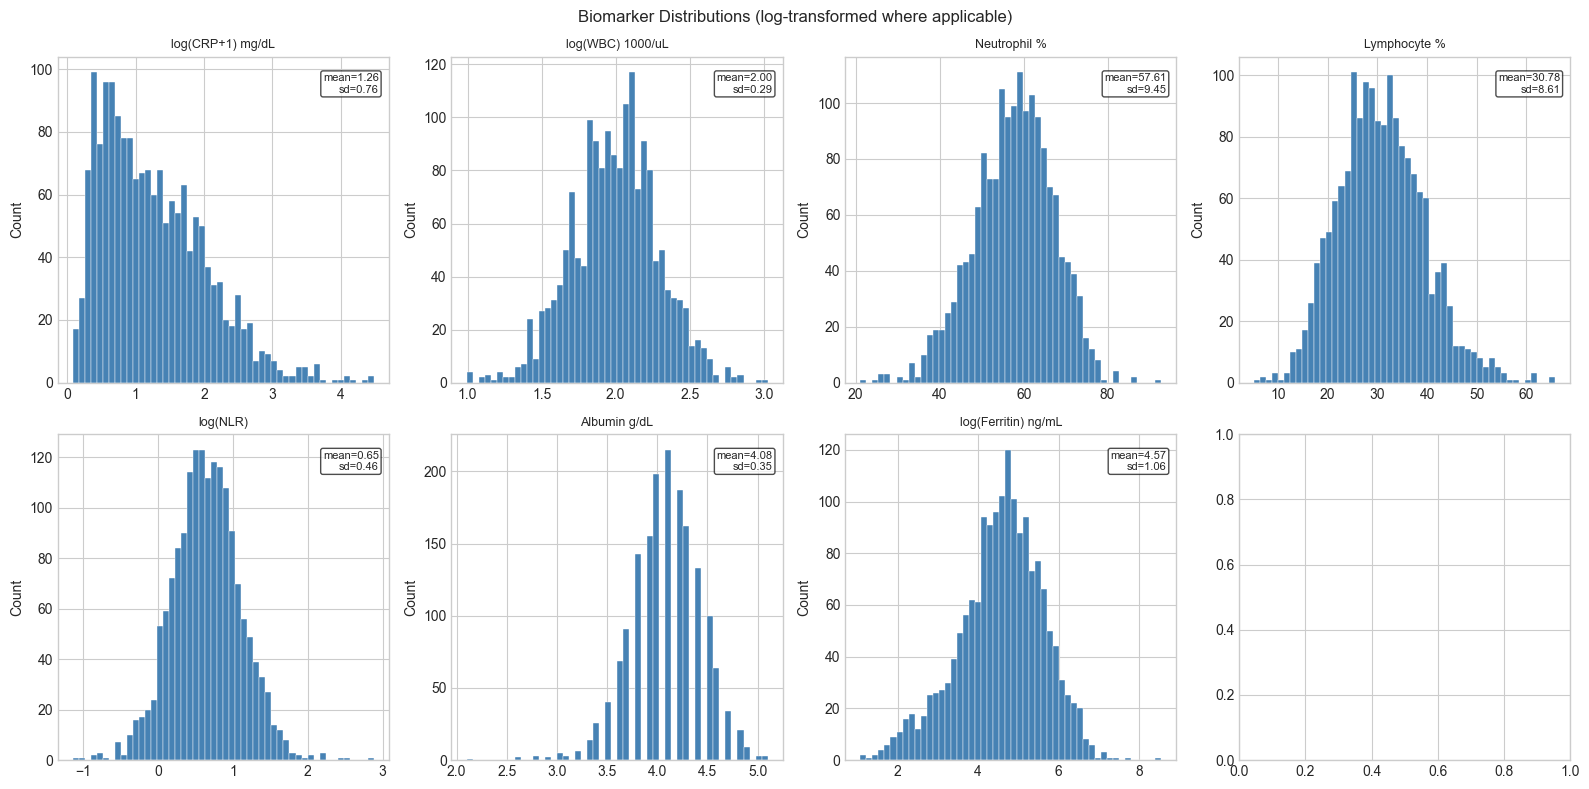

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (col, label) in zip(axes.flat, BIOMARKER_LABELS.items()):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'mean={data.mean():.2f}\nsd={data.std():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.suptitle('Biomarker Distributions (log-transformed where applicable)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'biomarker_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Biomarker Levels by Depression Status

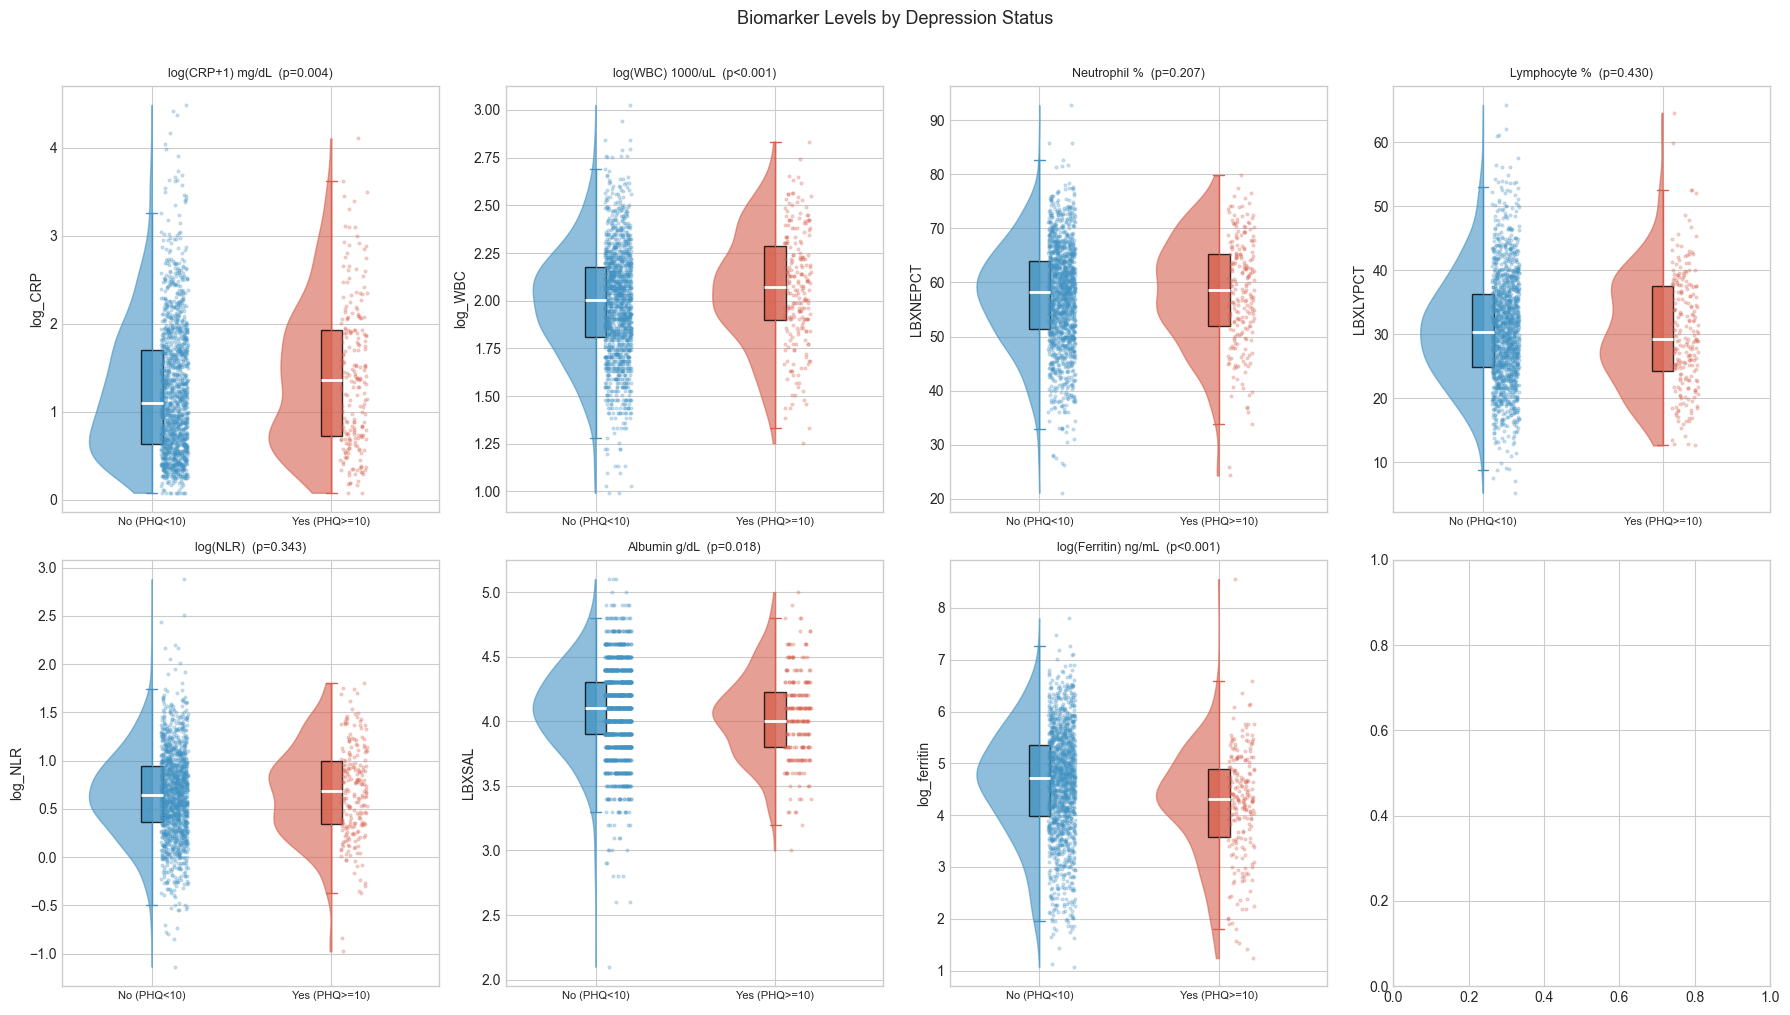

In [ ]:
from scipy.stats import gaussian_kde

def raincloud(ax, data, col, groups, colors, labels):
    """Half-violin + box + strip raincloud plot for two groups."""
    positions = [0, 1]
    for pos, (grp, color, label) in enumerate(zip(groups, colors, labels)):
        vals = data.loc[data['depression'] == grp, col].dropna().values
        if len(vals) < 5:
            continue

        # Half-violin (KDE) — drawn to the left of each position
        kde = gaussian_kde(vals, bw_method=0.3)
        y_range = np.linspace(vals.min(), vals.max(), 200)
        density = kde(y_range)
        density = density / density.max() * 0.35  # scale to half-width
        ax.fill_betweenx(y_range, pos - density, pos,
                         alpha=0.6, color=color)

        # Box plot
        bp = ax.boxplot(vals, positions=[pos], widths=0.12,
                        patch_artist=True, notch=False,
                        boxprops=dict(facecolor=color, alpha=0.8),
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color),
                        flierprops=dict(marker='', linestyle='none'),
                        manage_ticks=False)

        # Jittered strip
        np.random.seed(42)
        jitter = np.random.uniform(0.05, 0.2, size=len(vals))
        ax.scatter(pos + jitter, vals, alpha=0.25, s=4, color=color, zorder=2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlim(-0.5, 1.6)

df['Depression'] = df['depression'].map({0.0: 'No (PHQ<10)', 1.0: 'Yes (PHQ>=10)'})

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, (col, label) in zip(axes.flat, BIOMARKER_LABELS.items()):
    raincloud(ax, df, col,
              groups=[0.0, 1.0],
              colors=['#CA5995', '#FFB090'],
              labels=['No (PHQ<10)', 'Yes (PHQ>=10)'])
    a = df.loc[df['depression'] == 0, col].dropna()
    b = df.loc[df['depression'] == 1, col].dropna()
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax.set_title(f'{label}  ({p_str})', fontsize=9)
    ax.set_ylabel(col)

plt.suptitle('Biomarker Levels by Depression Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'biomarker_by_depression.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

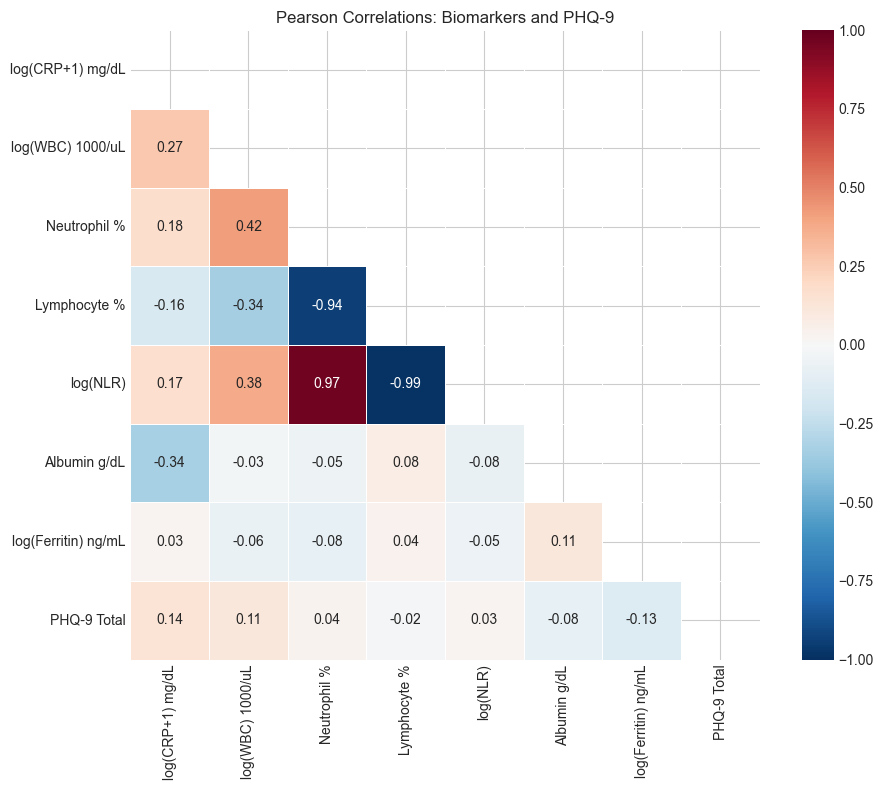

In [32]:
corr_cols   = list(BIOMARKER_LABELS.keys()) + ['PHQ9_total']
corr_labels = list(BIOMARKER_LABELS.values()) + ['PHQ-9 Total']

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            xticklabels=corr_labels, yticklabels=corr_labels, ax=ax)
ax.set_title('Pearson Correlations: Biomarkers and PHQ-9', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PHQ-9 Item Profiles by CRP Tertile

Preview of the symptom-level analysis: does the pattern of specific symptoms differ across CRP strata?

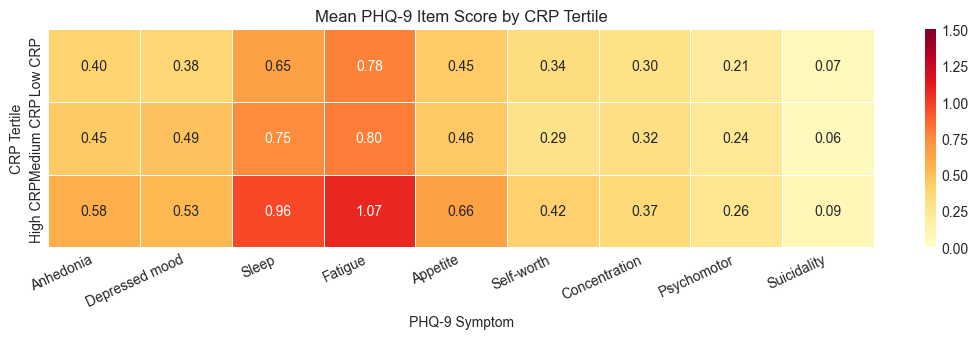

In [33]:
df['CRP_tertile'] = pd.qcut(df['log_CRP'], q=3, labels=['Low CRP', 'Medium CRP', 'High CRP'])

item_means = df.groupby('CRP_tertile', observed=True)[PHQ_ITEMS].mean()
item_means.columns = [ITEM_LABELS[c] for c in item_means.columns]

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(item_means, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1.5, linewidths=0.5, ax=ax)
ax.set_title('Mean PHQ-9 Item Score by CRP Tertile', fontsize=12)
ax.set_xlabel('PHQ-9 Symptom')
ax.set_ylabel('CRP Tertile')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIGURES / 'phq_items_by_crp_tertile.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. CRP vs PHQ-9 Score by Sex

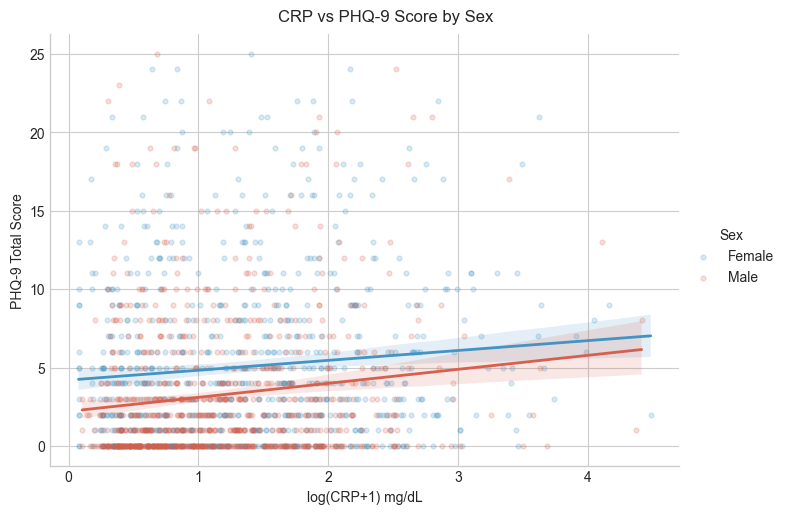

In [34]:
df['Sex'] = df['RIAGENDR'].map({1.0: 'Male', 2.0: 'Female'})

plot_df = df.dropna(subset=['log_CRP', 'PHQ9_total', 'Sex'])
plot_df = plot_df.sample(min(4000, len(plot_df)), random_state=42)

g = sns.lmplot(data=plot_df, x='log_CRP', y='PHQ9_total', hue='Sex',
               scatter_kws={'alpha': 0.2, 's': 12},
               line_kws={'linewidth': 2},
               palette=['#4393c3', '#d6604d'],
               height=5, aspect=1.4)
g.set_axis_labels('log(CRP+1) mg/dL', 'PHQ-9 Total Score')
g.figure.suptitle('CRP vs PHQ-9 Score by Sex', y=1.02)
plt.savefig(FIGURES / 'crp_vs_phq9_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()